# 02. 데이터 검증 (Data Validation)

**목표**: 수집된 corpus_raw.csv의 품질을 검증하고 보고서에 쓸 수 있는 전후 비교 결과 생성

| 검증 항목 | 내용 |
|----------|------|
| 결측치 | 컬럼별 null 비율 확인 및 처리 |
| 중복 | 동일 Q&A 중복 탐지 및 제거 |
| 클래스 불균형 | lifeCycle / department 분포 불균형 측정 |
| 이상치 | 텍스트 길이 극단값 탐지 |
| 레이블 일관성 | lifeCycle / department 값 표준화 |

> **다음 단계**: `03_preprocessing.ipynb` — KoNLPy 형태소 분석 + 프롬프트 최적화

## 0. 환경 설정

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from utils.config import DATA_PROCESSED

# 한글 폰트 설정
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

RAW_PATH       = DATA_PROCESSED / 'corpus_raw.csv'
VALIDATED_PATH = DATA_PROCESSED / 'corpus_validated.csv'

## 1. 데이터 로드

In [2]:
df = pd.read_csv(RAW_PATH)
df_original = df.copy()  # 전처리 전 원본 보존 (전후 비교용)

print(f"로드 완료: {len(df):,}개")
print(f"컬럼: {list(df.columns)}")
df.head(3)

로드 완료: 21,606개
컬럼: ['lifeCycle', 'department', 'disease', 'input', 'output', 'split']


,lifeCycle,department,disease,input,output,split
0,성견,안과,제3안검탈출증,저희 집에서 기르고 있는 것으로 7세 된 암컷 말티즈와 다른 견종 혼합 강아지에 대...,해당 증상은 제3안검이 라고 불리는 부분과 관련이 있습니다. 이는 정상적인 해부학적...,train
1,성견,안과,기타,저희 강아지가 어제 밤부터 한쪽 눈을 잘 뜨지 못하는 모습을 보였습니다. 눈을 살펴...,눈에 관련된 문제라 많은 걱정을 하시게 되실 것입니다. 눈을 제대로 뜨지 못하는 증...,train
2,성견,내과,기타,안녕하세요. 저는 3세에 2.56킬로그램인 말티즈를 양육하고 있는 보호자입니다. 제...,강아지의 그러한 증상은 여러 가지 원인으로 나타날 수 있습니다. 호흡기 경련이나 알...,train


## 2. 결측치 검사

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    '결측 수': missing,
    '결측 비율(%)': missing_pct
})
print("=== 결측치 현황 ===")
print(missing_report)

=== 결측치 현황 ===
            결측 수  결측 비율(%)
lifeCycle      0      0.00
department     0      0.00
disease        2      0.01
input          0      0.00
output         0      0.00
split          0      0.00


In [4]:
# 핵심 컬럼(input, output)에 결측치 있는 행 제거
before = len(df)
df = df.dropna(subset=['input', 'output'])
after = len(df)

print(f"결측치 제거: {before:,} → {after:,} ({before - after}행 제거)")

결측치 제거: 21,606 → 21,606 (0행 제거)


## 3. 중복 탐지 및 제거

In [5]:
# input 기준 완전 중복 탐지
dup_count = df.duplicated(subset=['input']).sum()
print(f"중복 Q&A 수: {dup_count:,}개 ({dup_count / len(df) * 100:.2f}%)")

before = len(df)
df = df.drop_duplicates(subset=['input']).reset_index(drop=True)
after = len(df)
print(f"중복 제거: {before:,} → {after:,} ({before - after}행 제거)")

중복 Q&A 수: 2개 (0.01%)
중복 제거: 21,606 → 21,604 (2행 제거)


## 4. 레이블 일관성 검사

In [6]:
print("=== lifeCycle 고유값 ===")
print(df['lifeCycle'].value_counts())

print("\n=== department 고유값 ===")
print(df['department'].value_counts())

=== lifeCycle 고유값 ===
lifeCycle
성견     7275
노령견    7169
자견     7160
Name: count, dtype: int64

=== department 고유값 ===
department
내과     11049
외과      5758
피부과     2834
안과      1085
치과       877
 치과        1
Name: count, dtype: int64


In [7]:
# 예상 외 값 탐지
VALID_LIFECYCLE   = {'자견', '성견', '노령견'}
VALID_DEPARTMENT  = {'내과', '안과', '외과', '치과', '피부과'}

invalid_lc   = df[~df['lifeCycle'].isin(VALID_LIFECYCLE)]
invalid_dept = df[~df['department'].isin(VALID_DEPARTMENT)]

print(f"비정상 lifeCycle: {len(invalid_lc)}행")
print(f"비정상 department: {len(invalid_dept)}행")

if len(invalid_lc) > 0:
    print(invalid_lc[['lifeCycle']].value_counts())
if len(invalid_dept) > 0:
    print(invalid_dept[['department']].value_counts())

비정상 lifeCycle: 0행
비정상 department: 1행
department
치과            1
Name: count, dtype: int64


## 5. 클래스 불균형 측정

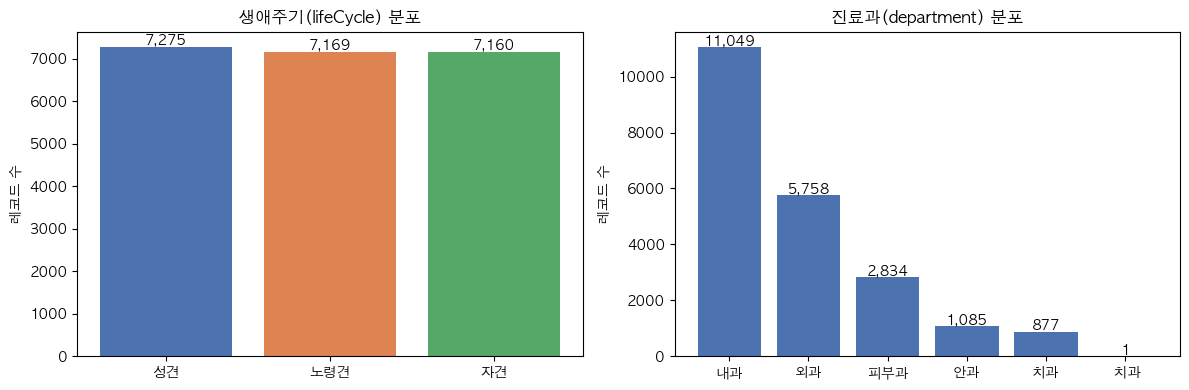

저장 완료: class_distribution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# lifeCycle 분포
lc_counts = df['lifeCycle'].value_counts()
axes[0].bar(lc_counts.index, lc_counts.values, color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('생애주기(lifeCycle) 분포')
axes[0].set_ylabel('레코드 수')
for i, v in enumerate(lc_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

# department 분포
dept_counts = df['department'].value_counts()
axes[1].bar(dept_counts.index, dept_counts.values, color='#4C72B0')
axes[1].set_title('진료과(department) 분포')
axes[1].set_ylabel('레코드 수')
for i, v in enumerate(dept_counts.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: class_distribution.png")

In [9]:
# 불균형 비율 계산 (최대/최소)
lc_ratio   = lc_counts.max() / lc_counts.min()
dept_ratio = dept_counts.max() / dept_counts.min()

print(f"lifeCycle 불균형 비율: {lc_ratio:.1f}x")
print(f"department 불균형 비율: {dept_ratio:.1f}x")
print("\n※ 5x 이상이면 분석 시 불균형 고려 필요")

lifeCycle 불균형 비율: 1.0x
department 불균형 비율: 11049.0x

※ 5x 이상이면 분석 시 불균형 고려 필요


## 6. 텍스트 길이 이상치 탐지

In [10]:
df['input_len']  = df['input'].str.len()
df['output_len'] = df['output'].str.len()

print("=== 텍스트 길이 통계 ===")
print(df[['input_len', 'output_len']].describe().round(1))

=== 텍스트 길이 통계 ===
       input_len  output_len
count    21604.0     21604.0
mean       329.6       394.6
std        254.7       266.3
min         25.0        18.0
25%        162.0       219.0
50%        258.0       317.0
75%        418.0       485.0
max       3208.0      3707.0


In [11]:
# IQR 방식으로 극단값 탐지
def detect_outliers(series: pd.Series, label: str) -> pd.Index:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    print(f"{label} 이상치: {len(outliers)}개 (범위 {lower:.0f} ~ {upper:.0f})")
    return outliers.index

input_outliers  = detect_outliers(df['input_len'],  'input 길이')
output_outliers = detect_outliers(df['output_len'], 'output 길이')

# 너무 짧은 텍스트 (10자 미만) 제거
before = len(df)
df = df[(df['input_len'] >= 10) & (df['output_len'] >= 10)]
print(f"\n너무 짧은 텍스트 제거: {before:,} → {len(df):,}")

input 길이 이상치: 1108개 (범위 -222 ~ 802)
output 길이 이상치: 1161개 (범위 -180 ~ 884)

너무 짧은 텍스트 제거: 21,604 → 21,604


## 7. 전후 비교 요약 (보고서 3번 항목)

In [12]:
removed = len(df_original) - len(df)

summary = pd.DataFrame({
    '항목': ['전체 레코드', '결측치 제거', '중복 제거', '이상치 제거', '최종 레코드'],
    '건수': [
        len(df_original),
        df_original.isnull().any(axis=1).sum(),
        df_original.duplicated(subset=['input']).sum(),
        len(input_outliers),
        len(df)
    ]
})
print(summary.to_string(index=False))

    항목    건수
전체 레코드 21606
결측치 제거     2
 중복 제거     2
이상치 제거  1108
최종 레코드 21604


## 8. 검증된 데이터 저장

In [13]:
# 길이 컬럼 제거 후 저장
df_clean = df.drop(columns=['input_len', 'output_len'])
df_clean.to_csv(VALIDATED_PATH, index=False, encoding='utf-8-sig')

print(f"저장 완료: {VALIDATED_PATH}")
print(f"최종 레코드: {len(df_clean):,}개")

저장 완료: /Users/user/Desktop/project/pet-health-ai/notebooks/../data/processed/corpus_validated.csv
최종 레코드: 21,604개


## 9. 검증 요약

| 항목 | 처리 전 | 처리 후 |
|------|--------|--------|
| 전체 레코드 | (실행 후 기입) | (실행 후 기입) |
| 결측치 제거 | - | (실행 후 기입)행 |
| 중복 제거 | - | (실행 후 기입)행 |
| 이상치 제거 | - | (실행 후 기입)행 |
| lifeCycle 불균형 | - | (실행 후 기입)x |
| department 불균형 | - | (실행 후 기입)x |
| 저장 파일 | - | `data/processed/corpus_validated.csv` |

> **다음 단계**: `03_preprocessing.ipynb` — KoNLPy 형태소 분석 + 프롬프트 최적화